In [15]:
from models.ViT.vit import ViT
from models.CNN.simple_cnn import SimpleCNN
from data.preprocessing import preprocess 
from data.image_dataset_train_test_split import image_dataset_train_test_split
from data.image_dataset import ImageDataset
from training.loop import fit, predict

from pathlib import Path
import torch

In [104]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# Obrada i učitavanje skupa podataka

In [11]:
preprocess(
    src_dir=Path("../data/raw"),
    dst_dir=Path("../data/processed"),
    img_size=224
)

/home/dell/miniconda3/envs/ri/lib/python3.8/site-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/dell/miniconda3/envs/ri/lib/python3.8/site-packages/PIL/Image.py:3368: DecompressionBombWarning: Image size (96714256 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Academic_Art: 1305 images found -> 1305 saved
Art_Nouveau: 3035 images found -> 3035 saved
Baroque: 5312 images found -> 5312 saved
Expressionism: 2607 images found -> 2607 saved
Japanese_Art: 2235 images found -> 2235 saved
Neoclassicism: 3115 images found -> 3115 saved
Primitivism: 1324 images found -> 1324 saved
Realism: 5373 images found -> 5373 saved
Renaissance: 6192 images found -> 6192 saved
Rococo: 2521 images found -> 2521 saved
Romanticism: 6813 images found -> 6813 saved
Symbolism: 1510 images found -> 1510 saved
Western_Medieval: 1158 images found -> 1158 saved


{'Academic_Art': 1305,
 'Art_Nouveau': 3035,
 'Baroque': 5312,
 'Expressionism': 2607,
 'Japanese_Art': 2235,
 'Neoclassicism': 3115,
 'Primitivism': 1324,
 'Realism': 5373,
 'Renaissance': 6192,
 'Rococo': 2521,
 'Romanticism': 6813,
 'Symbolism': 1510,
 'Western_Medieval': 1158}

In [81]:
class_counts = image_dataset_train_test_split(
                    src_path="../data/processed",
                    dest_path="../data/training",
                    test_size=0.2
                )

Academic_Art: 1305 found -> 1044 train, 261 test
Art_Nouveau: 3035 found -> 2428 train, 607 test
Baroque: 5312 found -> 4250 train, 1062 test
Expressionism: 2607 found -> 2086 train, 521 test
Japanese_Art: 2235 found -> 1788 train, 447 test
Neoclassicism: 3115 found -> 2492 train, 623 test
Primitivism: 1324 found -> 1060 train, 264 test
Realism: 5373 found -> 4299 train, 1074 test
Renaissance: 6192 found -> 4954 train, 1238 test
Rococo: 2521 found -> 2017 train, 504 test
Romanticism: 6813 found -> 5451 train, 1362 test
Symbolism: 1510 found -> 1208 train, 302 test
Western_Medieval: 1158 found -> 927 train, 231 test


In [100]:
train_dataset = ImageDataset("../data/training/train", augment=True, max_per_class=1000)

print("Num samples:", len(train_dataset))     
print("Classes:", train_dataset.classes)      
print("Weights:", train_dataset.weights)

Num samples: 12927
Classes: ['Academic_Art', 'Art_Nouveau', 'Baroque', 'Expressionism', 'Japanese_Art', 'Neoclassicism', 'Primitivism', 'Realism', 'Renaissance', 'Rococo', 'Romanticism', 'Symbolism', 'Western_Medieval']
Weights: tensor([1.0056, 1.0056, 1.0056, 1.0056, 1.0056, 1.0056, 1.0056, 1.0056, 1.0056,
        1.0056, 1.0056, 1.0056, 0.9322])


In [101]:
test_dataset = ImageDataset("../data/training/test", max_per_class=200);

print("Num samples:", len(test_dataset))     
print("Classes:", test_dataset.classes)      
print("Weights:", test_dataset.weights)

Num samples: 2600
Classes: ['Academic_Art', 'Art_Nouveau', 'Baroque', 'Expressionism', 'Japanese_Art', 'Neoclassicism', 'Primitivism', 'Realism', 'Renaissance', 'Rococo', 'Romanticism', 'Symbolism', 'Western_Medieval']
Weights: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


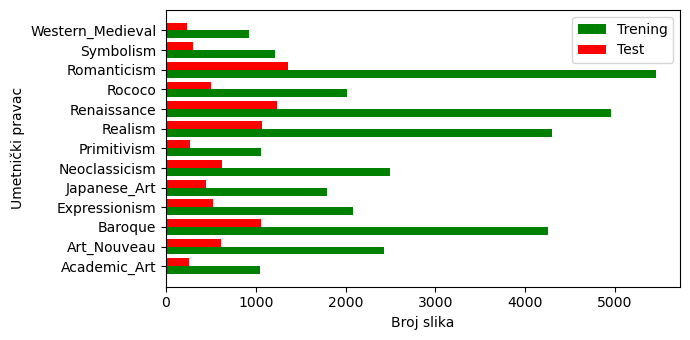

In [86]:
classes = list(class_counts.keys())
train = [class_counts[c]["train"] for c in classes]
test = [class_counts[c]["test"] for c in classes]

y = np.arange(len(classes))
height = 0.4

plt.figure(figsize=(7, 3.5))

plt.barh(y - height / 2, train, height, label="Trening", color="green")
plt.barh(y + height / 2, test, height, label="Test", color="red")

plt.ylabel("Umetnički pravac")
plt.xlabel("Broj slika")

plt.yticks(y, classes)
plt.legend()

plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Treniranje ViT modela

In [102]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ViT(img_size=224, in_channels=3, num_classes=len(dataset.classes), embed_dim=128,
            heads=4, N=4, P=16)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = torch.nn.CrossEntropyLoss(weight=dataset.weights)

history = fit(model, train_dataset, optimizer, criterion, device=device, epochs=20, batch_size=16)

epoch [1/20]
train loss: 2.2337, train accuracy: 0.1803
validation loss: 2.1379, validation accuracy: 0.2054
epoch [2/20]
train loss: 2.0267, train accuracy: 0.2530
validation loss: 1.9061, validation accuracy: 0.3075
epoch [3/20]
train loss: 1.9079, train accuracy: 0.2955
validation loss: 1.8807, validation accuracy: 0.2983
epoch [4/20]
train loss: 1.8237, train accuracy: 0.3292
validation loss: 1.7857, validation accuracy: 0.3327
epoch [5/20]
train loss: 1.7470, train accuracy: 0.3558
validation loss: 1.7618, validation accuracy: 0.3617
epoch [6/20]
train loss: 1.6945, train accuracy: 0.3671
validation loss: 1.7032, validation accuracy: 0.3714
epoch [7/20]
train loss: 1.6520, train accuracy: 0.3817
validation loss: 1.6692, validation accuracy: 0.3872
epoch [8/20]
train loss: 1.6084, train accuracy: 0.3980
validation loss: 1.6824, validation accuracy: 0.3756
epoch [9/20]
train loss: 1.5662, train accuracy: 0.4104
validation loss: 1.6706, validation accuracy: 0.3930
epoch [10/20]
train

# Evaluacija ViT modela

In [105]:
y_pred_vit = predict(model, test_dataset, batch_size=16, device=device)
y_test = torch.tensor([label for _, label in test_dataset.samples])

In [106]:
y_test.shape, y_pred_vit.shape

(torch.Size([2600]), torch.Size([2600]))

In [107]:
cm_vit = confusion_matrix(y_test, y_pred_vit)

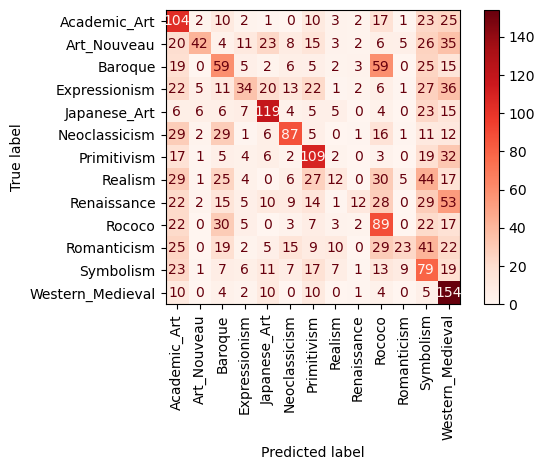

In [135]:
ConfusionMatrixDisplay(confusion_matrix=cm_vit, display_labels=test_dataset.classes).plot(xticks_rotation=90, cmap="Reds")

plt.savefig("ViTConfusionMatrix.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Treniranje CNN modela

In [103]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

cnn_model = SimpleCNN(in_channels=3, num_of_classes=len(dataset.classes), img_size=224)

optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=3e-4)
criterion = torch.nn.CrossEntropyLoss(weight=dataset.weights)

cnn_history = fit(cnn_model, train_dataset, optimizer, criterion, device=device, epochs=20, batch_size=16)

epoch [1/20]
train loss: 2.0336, train accuracy: 0.2430
validation loss: 1.9247, validation accuracy: 0.2851
epoch [2/20]
train loss: 1.8385, train accuracy: 0.3028
validation loss: 1.8548, validation accuracy: 0.2925
epoch [3/20]
train loss: 1.7281, train accuracy: 0.3415
validation loss: 1.7323, validation accuracy: 0.3412
epoch [4/20]
train loss: 1.6478, train accuracy: 0.3723
validation loss: 1.6112, validation accuracy: 0.3768
epoch [5/20]
train loss: 1.5789, train accuracy: 0.3978
validation loss: 1.7713, validation accuracy: 0.3219
epoch [6/20]
train loss: 1.5235, train accuracy: 0.4176
validation loss: 1.5684, validation accuracy: 0.3853
epoch [7/20]
train loss: 1.4728, train accuracy: 0.4394
validation loss: 1.4382, validation accuracy: 0.4306
epoch [8/20]
train loss: 1.4200, train accuracy: 0.4529
validation loss: 1.6160, validation accuracy: 0.4046
epoch [9/20]
train loss: 1.3753, train accuracy: 0.4768
validation loss: 1.4079, validation accuracy: 0.4801
epoch [10/20]
train

# Evaluacija CNN modela

In [112]:
y_pred_cnn = predict(cnn_model, test_dataset, batch_size=16, device=device)

In [113]:
y_test.shape, y_pred_cnn.shape

(torch.Size([2600]), torch.Size([2600]))

In [114]:
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

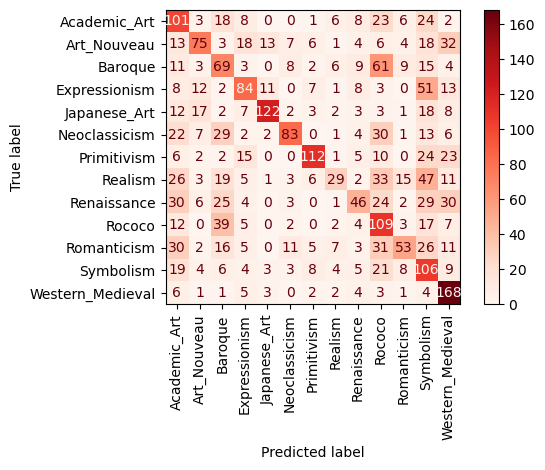

In [136]:
ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=test_dataset.classes).plot(xticks_rotation=90,cmap="Reds")

plt.savefig("CNNConfusionMatrix.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Poređenje ViT i CNN modela

In [116]:
results = {
        "Accuracy": [
            accuracy_score(y_test, y_pred_vit),
            accuracy_score(y_test, y_pred_cnn)
        ],
        "Macro Precision": [
            precision_score(y_test, y_pred_vit, average="macro", zero_division=0),
            precision_score(y_test, y_pred_cnn, average="macro", zero_division=0)
        ],
        "Macro Recall": [
            recall_score(y_test, y_pred_vit, average="macro", zero_division=0),
            recall_score(y_test, y_pred_cnn, average="macro", zero_division=0)
        ],
        "Macro F1": [
            f1_score(y_test, y_pred_vit, average="macro", zero_division=0),
            f1_score(y_test, y_pred_cnn, average="macro", zero_division=0)
        ],
        "Weighted F1": [
            f1_score(y_test, y_pred_vit, average="weighted", zero_division=0),
            f1_score(y_test, y_pred_cnn, average="weighted", zero_division=0)
        ]
    }

df = pd.DataFrame(results, index=["ViT", "CNN"])
print(df)

     Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1
ViT     0.355         0.401397         0.355  0.326498     0.326498
CNN     0.445         0.493543         0.445  0.441339     0.441339


In [137]:
def compare_class_accuracy(y_test, vit_pred, cnn_pred, class_names):
    y_test = np.array(y_test)
    vit_pred = np.array(vit_pred)
    cnn_pred = np.array(cnn_pred)

    vit_acc = []
    cnn_acc = []

    for i in range(len(class_names)):
        mask = y_test == i

        vit_acc.append(np.mean(vit_pred[mask] == y_test[mask]))
        cnn_acc.append(np.mean(cnn_pred[mask] == y_test[mask]))

    x = np.arange(len(class_names))
    width = 0.4

    plt.figure(figsize=(10, 6))

    plt.bar(x - width/2, vit_acc, width, label="ViT")
    plt.bar(x + width/2, cnn_acc, width, label="CNN")

    plt.xlabel("Umetnički period")
    plt.ylabel("Tačnost")
    plt.title("Tačnost ViT i CNN modela po klasama")
    plt.xticks(x, class_names, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.legend()

    plt.savefig("ClassAcc.png", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

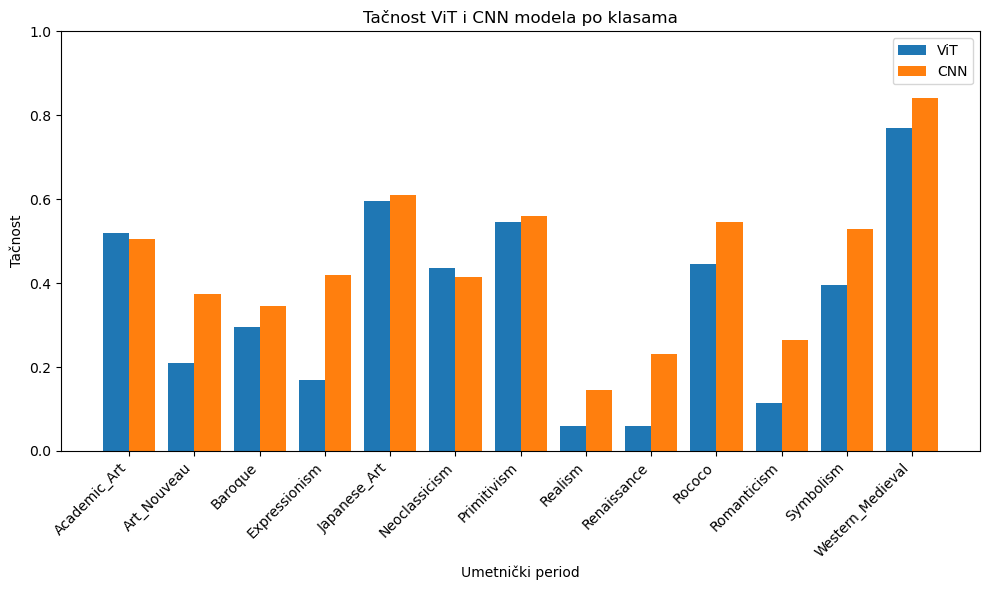

In [138]:
compare_class_accuracy(y_test, y_pred_vit, y_pred_cnn, test_dataset.classes)

In [139]:
def plot_accuracy(vit_history, cnn_history):
    vit_epochs = range(1, len(vit_history["train_acc"]) + 1)
    cnn_epochs = range(1, len(cnn_history["train_acc"]) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(vit_epochs, vit_history["train_acc"], marker="o", label="ViT - trening")
    plt.plot(vit_epochs, vit_history["val_acc"], marker="o", linestyle="--", label="ViT - validacija")

    plt.plot(cnn_epochs, cnn_history["train_acc"], marker="s", label="CNN - trening")
    plt.plot(cnn_epochs, cnn_history["val_acc"], marker="s", linestyle="--", label="CNN - validacija")

    plt.xlabel("Epoha")
    plt.ylabel("Tačnost")
    plt.title("Tačnost tokom treniranja")
    plt.xticks(range(1, max(len(vit_history["train_acc"]), len(cnn_history["train_acc"])) + 1))
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.savefig("TrainValEpochAcc.png", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

In [140]:
def plot_loss(vit_history, cnn_history):
    vit_epochs = range(1, len(vit_history["train_loss"]) + 1)
    cnn_epochs = range(1, len(cnn_history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(vit_epochs, vit_history["train_loss"], marker="o", label="ViT - trening")
    plt.plot(vit_epochs, vit_history["val_loss"], marker="o", linestyle="--", label="ViT - validacija")

    plt.plot(cnn_epochs, cnn_history["train_loss"], marker="s", label="CNN - trening")
    plt.plot(cnn_epochs, cnn_history["val_loss"], marker="s", linestyle="--", label="CNN - validacija")

    plt.xlabel("Epoha")
    plt.ylabel("Gubitak")
    plt.title("Gubitak tokom treniranja")
    plt.xticks(range(1, max(len(vit_history["train_loss"]), len(cnn_history["train_loss"])) + 1))
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.savefig("TrainValEpochLoss.png", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

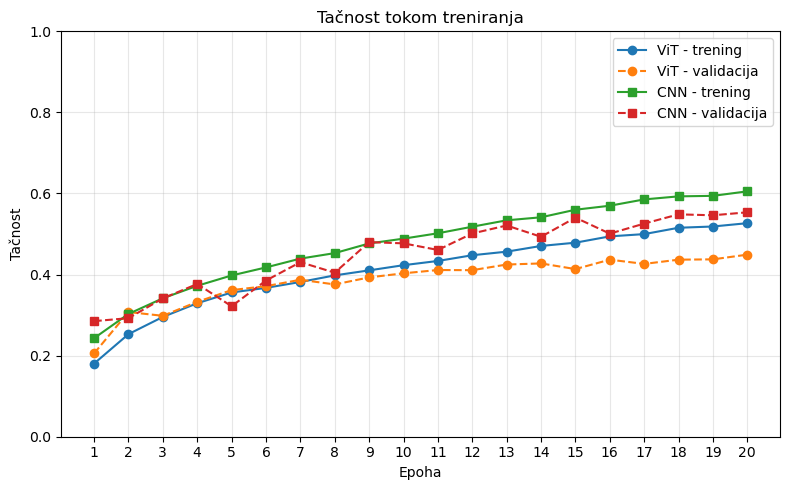

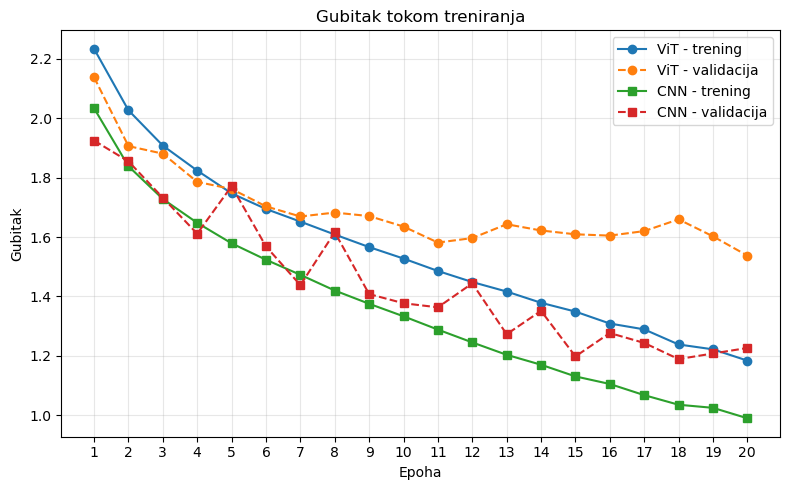

In [141]:
plot_accuracy(history, cnn_history)
plot_loss(history, cnn_history)